## Sivanjaneya

## Business Problem:

Food delivery companies want to estimate delivery time before assigning an order.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
df.shape

(1000, 9)

In [7]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [8]:
df.dtypes

Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

In [9]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [10]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [11]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [12]:
cat_cols = ['Weather','Traffic_Level','Time_of_Day']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [14]:
df.duplicated().sum()

0

## Target Variable Distribution

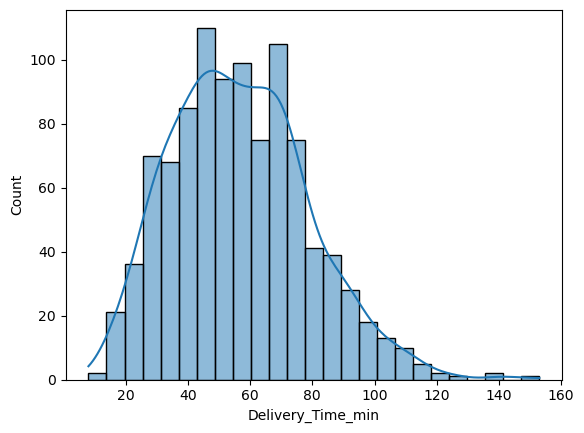

In [15]:
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.show()

##  Correlation Analysis

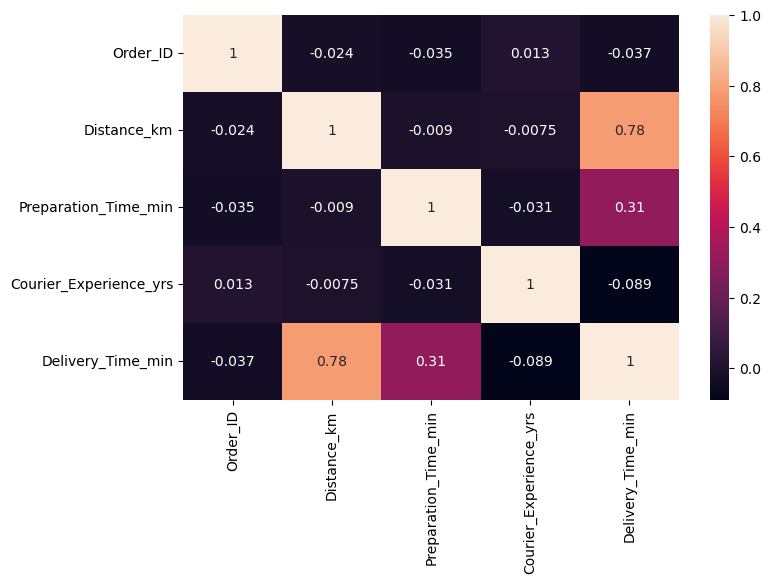

In [16]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(num_df.corr(), annot=True)
plt.show()

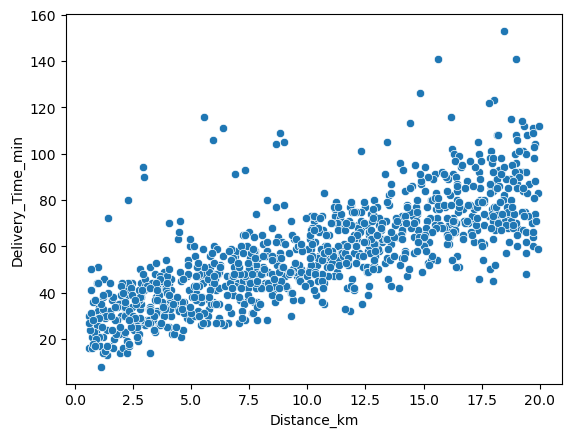

In [17]:
sns.scatterplot(
    x='Distance_km',
    y='Delivery_Time_min',
    data=df
)
plt.show()

<Axes: xlabel='Delivery_Time_min'>

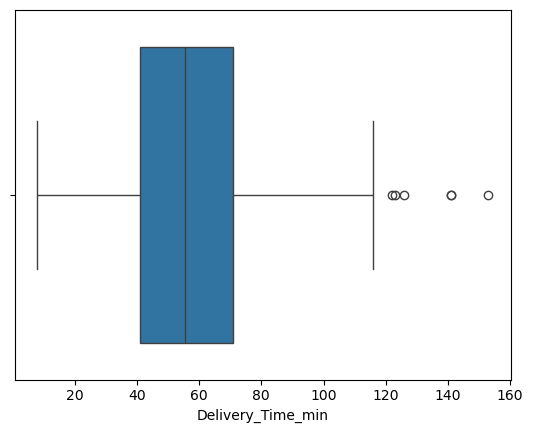

In [18]:
sns.boxplot(
    x=df['Delivery_Time_min']
)

<Axes: xlabel='Weather', ylabel='Delivery_Time_min'>

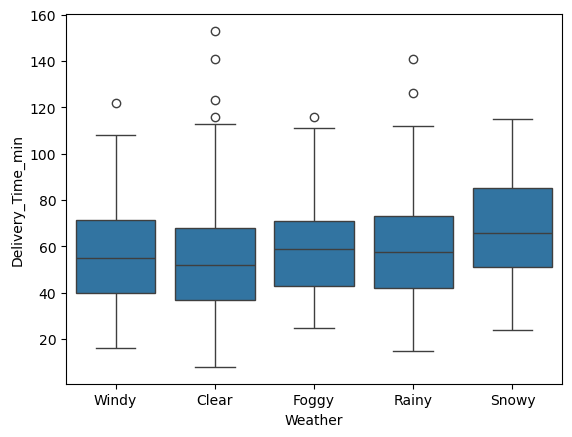

In [19]:
sns.boxplot(
    x='Weather',
    y='Delivery_Time_min',
    data=df
)   

<Axes: xlabel='Traffic_Level', ylabel='Delivery_Time_min'>

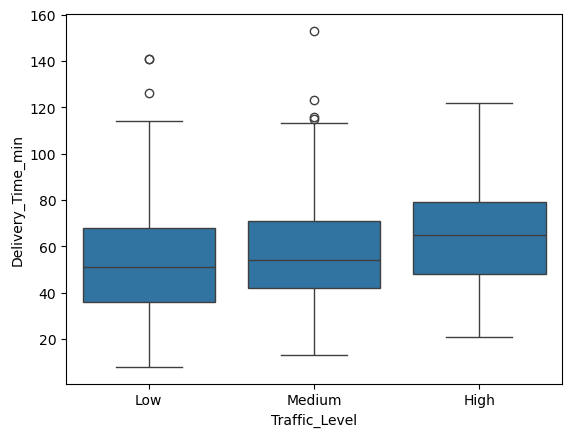

In [20]:
sns.boxplot(
    x='Traffic_Level',
    y='Delivery_Time_min',
    data=df
)

## Encode Categorical Variables
One-Hot Encoding

In [21]:
df = pd.get_dummies(
    df,
    columns=[
        'Weather',
        'Traffic_Level',
        'Time_of_Day',
        'Vehicle_Type'
    ],
    drop_first=True
)

## Simple Linear Regression

In [22]:
X_slr = df[['Distance_km']]
y_slr = df['Delivery_Time_min']

## Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(
    X_slr,
    y_slr,
    test_size=0.2,
    random_state=42
)

## Train Model

In [24]:
from sklearn.linear_model import LinearRegression

slr_model = LinearRegression()

slr_model.fit(
    X_train_slr,
    y_train_slr
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Prediction

In [25]:
y_pred_slr = slr_model.predict(
    X_test_slr
)

## Evaluation

In [26]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test_slr, y_pred_slr))

print("RMSE :", np.sqrt(
    mean_squared_error(y_test_slr, y_pred_slr)
))

print("R2 Score :", r2_score(
    y_test_slr,
    y_pred_slr
))

MAE : 9.580954148917813
RMSE : 12.576246151884975
R2 Score : 0.6471386683659509


## Intercept and Coefficient

In [27]:
print("Intercept :", slr_model.intercept_)

print("Coefficient :", slr_model.coef_[0])

Intercept : 26.585748176869696
Coefficient : 3.0164695806793


## Regression Line Visualization

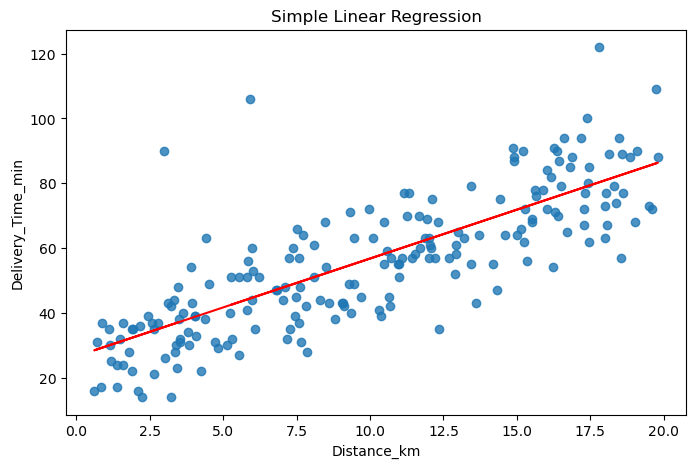

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    X_test_slr,
    y_test_slr,
    alpha=0.8
)

plt.plot(
    X_test_slr,
    y_pred_slr,
    color='red'
)

plt.xlabel("Distance_km")
plt.ylabel("Delivery_Time_min")
plt.title("Simple Linear Regression")

plt.show()

## Cross Validation

In [29]:
from sklearn.model_selection import cross_val_score

slr_cv_scores = cross_val_score(
    slr_model,
    X_slr,
    y_slr,
    cv=5,
    scoring='r2'
)

print("Fold Scores:")
print(slr_cv_scores)

print("Average CV Score:")
print(slr_cv_scores.mean())

Fold Scores:
[0.52131557 0.65591786 0.62963621 0.60411533 0.6354089 ]
Average CV Score:
0.6092787733512411


## Multiple Linear Regression

## Define X and y

In [30]:
X = df.drop(
    ['Order_ID','Delivery_Time_min'],
    axis=1
)

y = df['Delivery_Time_min']

## Train-Test Split

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Multiple Linear model

In [33]:
from sklearn.linear_model import LinearRegression

mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

# y_pred_mlr = mlr_model.predict(X_test)
# y_pred_train=mlr_model.predict(y_train)


# Predictions
y_pred_mlr = mlr_model.predict(X_test)

# Metrics
train_r2 = mlr_model.score(X_train,y_train)
test_r2 = r2_score(y_test,y_pred_mlr)

In [34]:
print("Intercept:", mlr_model.intercept_)

Intercept: 17.367578505419083


In [35]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
5,Weather_Snowy,9.246816
3,Weather_Foggy,5.816452
4,Weather_Rainy,4.639445
0,Distance_km,3.001304
6,Weather_Windy,1.446947
9,Time_of_Day_Evening,1.004784
1,Preparation_Time_min,0.969158
12,Vehicle_Type_Car,0.517729
10,Time_of_Day_Morning,-0.169274
2,Courier_Experience_yrs,-0.677165


## MLR Model Evaluation

In [36]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE :", mean_absolute_error(y_test, y_pred_mlr))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_mlr)))

print("Train R2 :", train_r2)
print("Test R2  :", test_r2)

MAE : 5.8991686983534874
RMSE : 8.826470149873378
Train R2 : 0.7630020365990979
Test R2  : 0.8261894538886113


## Multiple Linear Regression Cross Validation

In [37]:
from sklearn.model_selection import cross_val_score

mlr = LinearRegression()

mlr_cv_scores = cross_val_score(
    mlr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Fold Scores:")
print(mlr_cv_scores)

print("\nAverage R2:")
print(mlr_cv_scores.mean())

Fold Scores:
[0.70307888 0.80689978 0.78757919 0.75516701 0.78994626]

Average R2:
0.7685342237868473


## RMSE Using Cross Validation

In [38]:
from sklearn.model_selection import cross_val_score
import numpy as np

rmse_scores = np.sqrt(
    -cross_val_score(
        mlr,
        X,
        y,
        cv=5,
        scoring='neg_mean_squared_error'
    )
)

print("RMSE Scores:")
print(rmse_scores)

print("\nAverage RMSE:")
print(rmse_scores.mean())

RMSE Scores:
[12.29734087  9.92886146 10.20924501 10.69996659  9.72512432]

Average RMSE:
10.572107649846439


## MLR-Actual vs Predicted

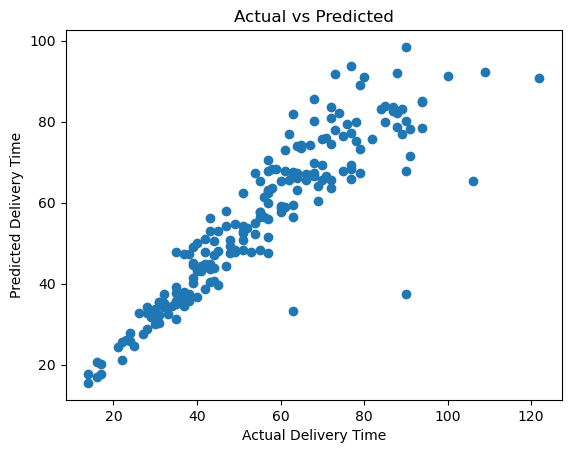

In [39]:
plt.scatter(y_test, y_pred_mlr)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted")
plt.show()

## Polynomial Regression

In [40]:
X = df.drop(
    ['Order_ID', 'Delivery_Time_min'],
    axis=1
)

y = df['Delivery_Time_min']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [43]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

In [44]:
poly_model = LinearRegression()

poly_model.fit(
    X_train_poly,
    y_train
)

y_pred_poly = poly_model.predict(
    X_test_poly
)
y_pred_train = poly_model.predict(
    X_train_poly
)

## poly Model Evaluation

In [45]:
print("MAE :", mean_absolute_error(y_test,y_pred_poly))

print("RMSE :", np.sqrt(mean_squared_error(y_test,y_pred_poly)))

print("R2 Score :", r2_score(y_test,y_pred_poly))
print("R2 Score :", r2_score(y_train,y_pred_train))

MAE : 6.873405954806144
RMSE : 9.667947162896493
R2 Score : 0.7914690378807336
R2 Score : 0.785652188994613


## Polynomial Regression Cross Validation

In [46]:
from sklearn.pipeline import Pipeline

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

poly_cv_scores = cross_val_score(
    poly_pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Polynomial Fold Scores:")
print(poly_cv_scores)

print("\nAverage R2:")
print(poly_cv_scores.mean())

Polynomial Fold Scores:
[0.70227754 0.78263449 0.76970984 0.71471187 0.76614338]

Average R2:
0.7470954236736975


## Polynomial RMSE -cross validation

In [47]:
poly_rmse = np.sqrt(
    -cross_val_score(
        poly_pipeline,
        X,
        y,
        cv=5,
        scoring='neg_mean_squared_error'
    )
)

print("Polynomial RMSE Scores:")
print(poly_rmse)

print("\nAverage RMSE:")
print(poly_rmse.mean())

Polynomial RMSE Scores:
[12.31392379 10.53424432 10.62998839 11.55019472 10.26135672]

Average RMSE:
11.057941589313469


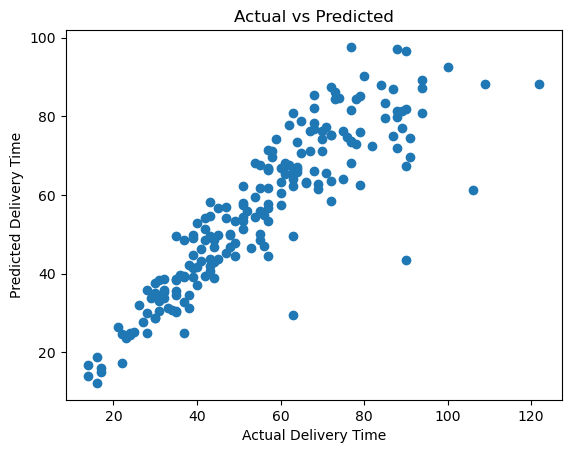

In [48]:
plt.scatter(y_test, y_pred_poly)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted")
plt.show()

In [49]:
comparison = pd.DataFrame({

    "Model":[
        "Multiple Linear Regression",
        "Polynomial Regression"
    ],

    "Cross Val R2":[
        mlr_cv_scores.mean(),
        poly_cv_scores.mean()
    ],

    "Cross Val RMSE":[
        rmse_scores.mean(),
        poly_rmse.mean()
    ]
})

comparison

,Model,Cross Val R2,Cross Val RMSE
0,Multiple Linear Regression,0.768534,10.572108
1,Polynomial Regression,0.747095,11.057942


In [50]:
comparison = pd.DataFrame({

    "Model":[
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression"
    ],

    "R2 Score":[
        r2_score(y_test_slr,y_pred_slr),
        r2_score(y_test,y_pred_mlr),
        r2_score(y_test,y_pred_poly)
    ]
})

comparison

,Model,R2 Score
0,Simple Linear Regression,0.647139
1,Multiple Linear Regression,0.826189
2,Polynomial Regression,0.791469


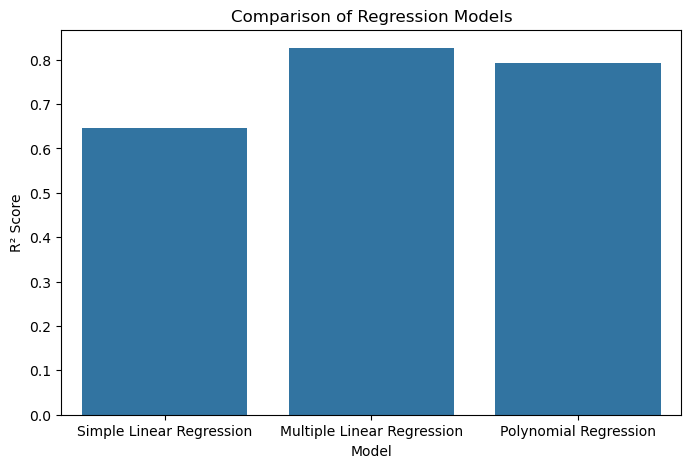

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='R2 Score'
)

plt.title('Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R² Score')

plt.show()

In [52]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
5,Weather_Snowy,9.246816
3,Weather_Foggy,5.816452
4,Weather_Rainy,4.639445
0,Distance_km,3.001304
6,Weather_Windy,1.446947
9,Time_of_Day_Evening,1.004784
1,Preparation_Time_min,0.969158
12,Vehicle_Type_Car,0.517729
10,Time_of_Day_Morning,-0.169274
2,Courier_Experience_yrs,-0.677165


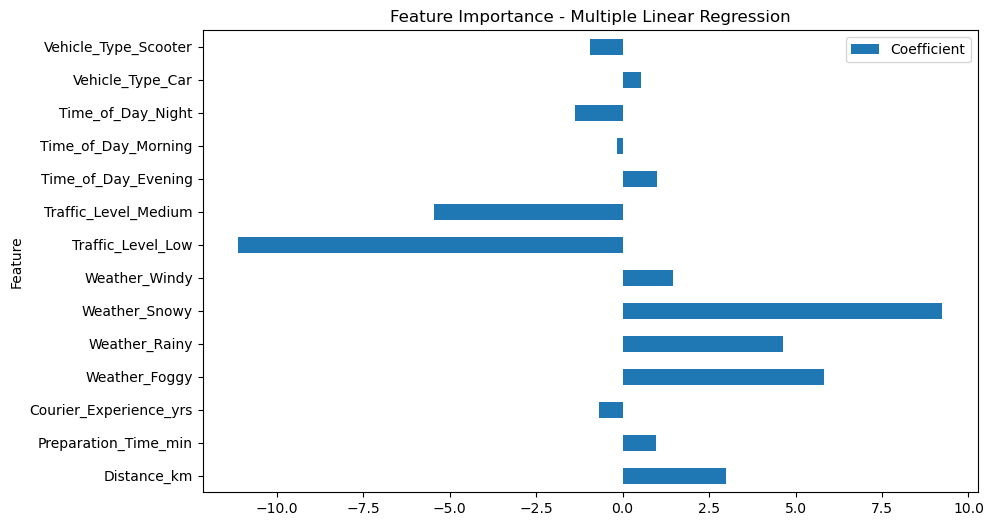

In [53]:
import matplotlib.pyplot as plt

coef_df.head(15).plot(
    x='Feature',
    y='Coefficient',
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance - Multiple Linear Regression")
plt.show()

## Delivery Time Estimation

Distance_km = 12
Weather = Rainy
Traffic_Level = Medium
Time_of_Day = Evening
Vehicle_Type = Scooter
Preparation_Time_min = 20
Courier_Experience_yrs = 2

In [54]:
new_order = pd.DataFrame({
    'Distance_km':[15],
    'Preparation_Time_min':[20],
    'Courier_Experience_yrs':[2],

    'Weather_Foggy':[0],
    'Weather_Rainy':[1],
    'Weather_Snowy':[0],
    'Weather_Windy':[0],

    'Traffic_Level_Low':[0],
    'Traffic_Level_Medium':[1],
    
    'Time_of_Day_Evening':[1],
    'Time_of_Day_Morning':[0],
    'Time_of_Day_Night':[0],

    'Vehicle_Type_Car':[0],
    'Vehicle_Type_Scooter':[1]
})

## Multiple Linear Regression - Delivery Time Estimation

In [55]:
pred = mlr_model.predict(new_order)

print(
    "Estimated Delivery Time:",
    round(pred[0],2),
    "minutes"
)

Estimated Delivery Time: 79.67 minutes


## Polynomial Regression - Delivery Time Estimation

In [56]:
pred_poly = poly_model.predict(
    poly.transform(new_order)
)

print(
    "Estimated Delivery Time:",
    round(pred_poly[0],2),
    "minutes"
)

Estimated Delivery Time: 80.5 minutes


## Regularization

## Ridge

In [57]:
X = df.drop(
    ['Order_ID','Delivery_Time_min'],
    axis=1
)

y = df['Delivery_Time_min']

In [58]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [60]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_params = {
    'alpha':[0.01,0.1,1,10,100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(
    X_train_scaled,
    y_train
)

best_ridge = ridge_grid.best_estimator_

In [61]:
ridge_pred = best_ridge.predict(
    X_test_scaled
)

In [62]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np

print("Best Alpha:",
      ridge_grid.best_params_)

print("R2:",
      r2_score(y_test,ridge_pred))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              ridge_pred
          )
      ))

Best Alpha: {'alpha': 1}
R2: 0.8261032991418965
RMSE: 8.82865743973044


## Lasso

In [63]:
from sklearn.linear_model import Lasso

lasso_params = {
    'alpha':[0.001,0.01,0.1,1,10]
}

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_params,
    cv=5,
    scoring='r2'
)

lasso_grid.fit(
    X_train_scaled,
    y_train
)

best_lasso = lasso_grid.best_estimator_

In [64]:
lasso_pred = best_lasso.predict(
    X_test_scaled
)

In [65]:
print("Best Alpha:",
      lasso_grid.best_params_)

print("R2:",
      r2_score(y_test,lasso_pred))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              lasso_pred
          )
      ))

Best Alpha: {'alpha': 0.01}
R2: 0.825938674939533
RMSE: 8.832835399595355


## ElasticNet

In [66]:
from sklearn.linear_model import ElasticNet

elastic_params = {
    'alpha':[0.001,0.01,0.1,1],
    'l1_ratio':[0.1,0.3,0.5,0.7,0.9]
}

elastic_grid = GridSearchCV(
    ElasticNet(max_iter=10000),
    elastic_params,
    cv=5,
    scoring='r2'
)

elastic_grid.fit(
    X_train_scaled,
    y_train
)

best_elastic = elastic_grid.best_estimator_

In [67]:
elastic_pred = best_elastic.predict(
    X_test_scaled
)

In [68]:
print("Best Parameters:",
      elastic_grid.best_params_)

print("R2:",
      r2_score(y_test,elastic_pred))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              elastic_pred
          )
      ))

Best Parameters: {'alpha': 0.01, 'l1_ratio': 0.3}
R2: 0.8255950278908198
RMSE: 8.841550377250428


In [69]:
from sklearn.model_selection import cross_val_score

ridge_cv = cross_val_score(
    best_ridge,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print(ridge_cv.mean())

0.752556379985671


In [70]:
lasso_cv = cross_val_score(
    best_lasso,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print(lasso_cv.mean())

0.7525800338691738


In [71]:
elastic_cv = cross_val_score(
    best_elastic,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print(elastic_cv.mean())

0.7526093581126948


In [72]:
results = pd.DataFrame({

    'Model':[
        'Simple LR',
        'Multiple LR',
        'Polynomial',
        'Ridge',
        'Lasso',
        'Elastic Net'
    ],

    'cv Score':[
        slr_cv_scores.mean(),
        mlr_cv_scores.mean(),
        poly_cv_scores.mean(),
        ridge_cv.mean(),
        lasso_cv.mean(),
        elastic_cv.mean()
    ]
})

results

,Model,cv Score
0,Simple LR,0.609279
1,Multiple LR,0.768534
2,Polynomial,0.747095
3,Ridge,0.752556
4,Lasso,0.752580
5,Elastic Net,0.752609


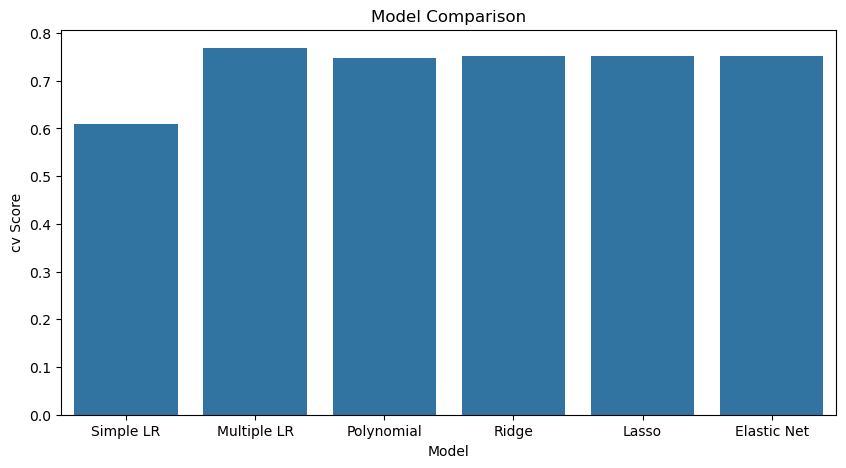

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x='Model',
    y='cv Score'
)

plt.title("Model Comparison")
plt.show()

## Conclusion

This project successfully developed and compared multiple machine learning models for food delivery time estimation. The analysis revealed that weather conditions, traffic levels, delivery distance, and preparation time are the most significant factors affecting delivery duration.

Among all models, Polynomial Regression provided the highest predictive performance by capturing nonlinear relationships and interactions between variables, while Multiple Linear Regression offered the best interpretability for business decision-making. Ridge, Lasso, and Elastic Net further improved model robustness through regularization techniques.

Overall, the developed solution can help food delivery companies improve ETA accuracy, optimize operations, and enhance customer satisfaction through data-driven decision-making.